# Object Detection su video con YOLO pre-addestrato

Questo notebook usa un modello **YOLO** pre-addestrato (libreria `ultralytics`) per fare object detection su un video fornito in input, frame per frame, e salvare il risultato in un nuovo file video con le bounding box disegnate.

## 1. Installazione delle dipendenze

Esegui questa cella solo se non hai già `ultralytics` e `opencv-python` installati.

In [14]:
%pip install -q ultralytics opencv-python

Note: you may need to restart the kernel to use updated packages.


## 2. Import

In [15]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
#import pandas as pd

In [16]:
import os
from pathlib import Path

BASE_DIR = Path.cwd().parent # due cartelle indietro
#print(BASE_DIR)

## 3. Parametri

- `SOURCE_VIDEO`: percorso del video di input
- `OUTPUT_VIDEO`: percorso del video di output con le detection disegnate
- `MODEL_NAME`: modello YOLO pre-addestrato da usare (verrà scaricato automaticamente al primo utilizzo)
- `CONF_THRESHOLD`: soglia minima di confidenza per mostrare una detection

In [17]:
from pathlib import Path

BASE_DIR = Path.cwd().parent
CONF_THRESHOLD = 0.20
MODEL_NAME = "yolov8n.pt"

SOURCE_VIDEO = BASE_DIR / "DATA" / "render" / "splacto_living_room.mp4"

conf_str = str(CONF_THRESHOLD).replace(".", "_")
OUTPUT_VIDEO = BASE_DIR / "DATA" / "output" / f"living_room_ct_{conf_str}.mp4"

print(OUTPUT_VIDEO)

/Users/salvatoremariocarota/Documents/Github/ComputerVisionLAB/DATA/output/living_room_ct_0_2.mp4


## 4. Caricamento del modello pre-addestrato

In [18]:
model = YOLO(MODEL_NAME)

In [19]:
from utility import print_classes_table
print_classes_table(model)

  4 | airplane           15 | cat                33 | kite               31 | snowboard         
 47 | apple              67 | cell phone         43 | knife              44 | spoon             
 24 | backpack           56 | chair              63 | laptop             32 | sports ball       
 46 | banana             74 | clock              68 | microwave          11 | stop sign         
 34 | baseball bat       57 | couch               3 | motorcycle         28 | suitcase          
 35 | baseball glove     19 | cow                64 | mouse              37 | surfboard         
 21 | bear               41 | cup                49 | orange             77 | teddy bear        
 59 | bed                60 | dining table       69 | oven               38 | tennis racket     
 13 | bench              16 | dog                12 | parking meter      27 | tie               
  1 | bicycle            54 | donut               0 | person             70 | toaster           
 14 | bird               20 | 

## 5. Funzione di inferenza sul video

La funzione legge il video frame per frame, esegue la detection con YOLO, disegna le bounding box e salva il tutto in un nuovo file video.

In [20]:
from yolo_video_detection import *

## 6. Esecuzione

Esegue l'inferenza sul video e, opzionalmente, conserva i primi frame annotati per una preview qui sotto.

In [21]:
preview_frames = run_inference(
    SOURCE_VIDEO,
    OUTPUT_VIDEO,
    model,
    conf=CONF_THRESHOLD,
    max_preview_frames=4,
)

Frame elaborati: 30
Frame elaborati: 60
Frame elaborati: 90
Frame elaborati: 120
Completato! Video salvato


## 7. Anteprima di alcuni frame con le detection

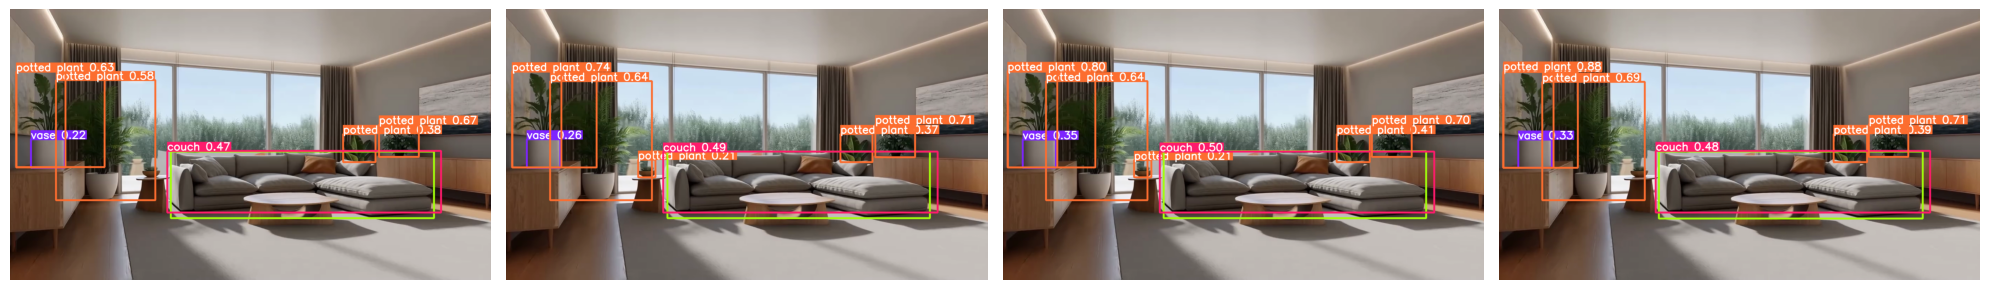

In [22]:
if preview_frames:
    n = len(preview_frames)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, frame in zip(axes, preview_frames):
        ax.imshow(frame)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Nessun frame di anteprima disponibile (max_preview_frames=0).")

## 8. Attacco Adversarial su YOLO

Gli **attacchi adversarial** (avversariali) sono perturbazioni, spesso impercettibili all'occhio umano, applicate a un input affinche' un modello di machine learning produca un output errato. Anche i modelli di object detection come YOLO sono vulnerabili a questo tipo di attacchi.

### Tassonomia degli attacchi

**In base alla conoscenza del modello (threat model):**
- **White-box**: l'attaccante conosce pesi e architettura del modello e puo' calcolare i gradienti direttamente (caso di questo notebook, dato che abbiamo accesso completo a YOLO).
- **Black-box**: l'attaccante non ha accesso ai pesi, solo all'output (attacchi query-based o transfer-based).

**In base allo spazio della perturbazione:**
- **Perturbazione digitale (pixel-level)**: si modifica direttamente l'immagine/i pixel in input (es. FGSM, PGD, C&W). Tipicamente impercettibile, ma richiede accesso diretto al file digitale.
- **Adversarial patch (fisico)**: si genera una "patch" (es. un adesivo) da posizionare fisicamente nella scena, robusta a diverse condizioni di luce e prospettiva.

**In base all'obiettivo:**
- **Untargeted / hiding attack**: l'obiettivo e' far "scomparire" gli oggetti, riducendo la confidenza delle detection sotto la soglia.
- **Targeted / spoofing attack**: l'obiettivo e' far classificare un oggetto come un'altra classe specifica, oppure far apparire detection inesistenti.

### Attacco implementato in questo notebook

Implementiamo un **attacco FGSM (Fast Gradient Sign Method)**: white-box, digitale, untargeted, di tipo *hiding*. L'obiettivo e' ridurre la confidenza delle detection di YOLO su un singolo frame, calcolando il gradiente della confidenza rispetto ai pixel di input e spostando l'immagine nella direzione che la riduce.

### Come funziona FGSM

FGSM calcola il gradiente di una funzione di perdita $L$ rispetto all'immagine di input $x$, e applica una perturbazione proporzionale al segno di questo gradiente:

$$x_{adv} = x - \epsilon \cdot \text{sign}(\nabla_x L)$$

In questo caso $L$ e' definita come la somma delle confidenze massime di classe predette da YOLO su tutte le anchor: spostandoci nella direzione che minimizza $L$, l'immagine perturbata fa abbassare le confidenze delle detection.

- $\epsilon$ controlla l'intensita' della perturbazione (piu' alto = perturbazione piu' visibile ma piu' efficace).
- La perturbazione viene applicata in un solo passo (a differenza di **PGD**, che itera FGSM piu' volte con step piu' piccoli e proietta il risultato in una palla di raggio $\epsilon$, risultando piu' efficace ma piu' costoso).

In [23]:
import torch
import numpy as np
import cv2
from adversarial import *

In [ ]:
# Estrai un frame di test e applica l'attacco
frame_tensor, frame_rgb = load_frame_as_tensor(SOURCE_VIDEO, frame_index=0, imgsz=640)

EPSILON = 0.05  # intensita' della perturbazione (provare valori tra 0.01 e 0.1)
adv_tensor, perturbation = fgsm_attack(model, frame_tensor, epsilon=EPSILON)

orig_img = tensor_to_image(frame_tensor.detach())
adv_img = tensor_to_image(adv_tensor)

# Inferenza YOLO su immagine originale e immagine adversarial
results_orig = model(orig_img, conf=CONF_THRESHOLD, verbose=False)
results_adv = model(adv_img, conf=CONF_THRESHOLD, verbose=False)

annotated_orig = results_orig[0].plot()
annotated_adv = results_adv[0].plot()

print(f"Detection sull'immagine originale:   {len(results_orig[0].boxes)}")
print(f"Detection sull'immagine adversarial: {len(results_adv[0].boxes)}")

Detection sull'immagine originale:   8
Detection sull'immagine adversarial: 8


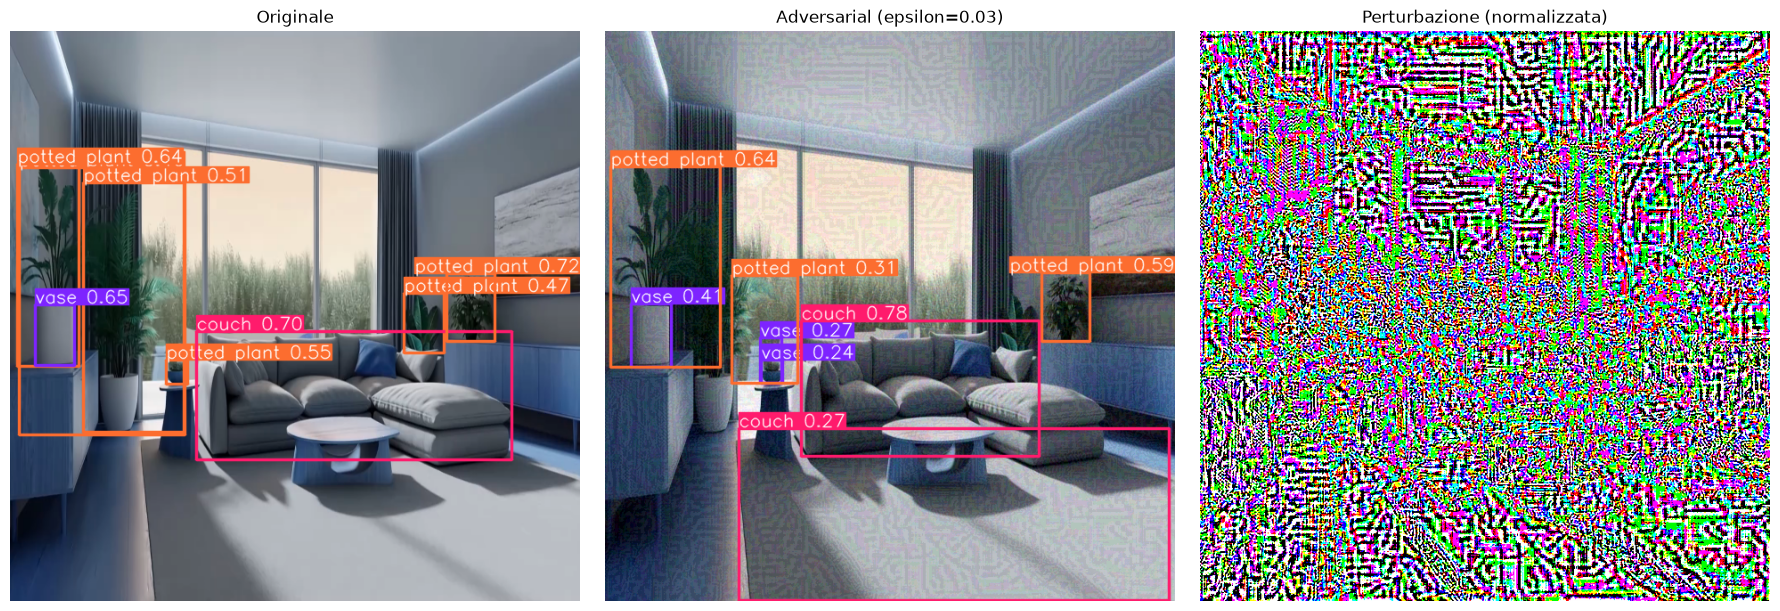

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(annotated_orig, cv2.COLOR_BGR2RGB))
axes[0].set_title("Originale")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(annotated_adv, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Adversarial (epsilon={EPSILON})")
axes[1].axis("off")

# Visualizza la perturbazione amplificata/normalizzata per renderla visibile
pert_vis = perturbation.squeeze(0).permute(1, 2, 0).cpu().numpy()
pert_vis = (pert_vis - pert_vis.min()) / (pert_vis.max() - pert_vis.min() + 1e-8)
axes[2].imshow(pert_vis)
axes[2].set_title("Perturbazione (normalizzata)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Da FGSM a PGD

**PGD (Projected Gradient Descent)** e' la versione iterativa di FGSM: invece di applicare un solo step di intensita' $\epsilon$, applica $T$ step piccoli di intensita' $\alpha$, proiettando ad ogni iterazione la perturbazione totale nella palla $L_\infty$ di raggio $\epsilon$:

$$x_{t+1} = \text{clip}_{x,\epsilon}\left(x_t - \alpha \cdot \text{sign}(\nabla_x L)\right)$$

PGD e' generalmente molto piu' efficace di FGSM a parita' di $\epsilon$, perche' segue il gradiente in modo piu' preciso, a costo di un numero di forward/backward pass pari a `num_iter`.

Parametri tipici:
- `epsilon`: stesso significato di FGSM, limite massimo della perturbazione (norma $L_\infty$).
- `alpha`: step size per iterazione, tipicamente `epsilon / 4` ~ `epsilon / 10`.
- `num_iter`: numero di iterazioni (es. 10-40, piu' iterazioni = attacco piu' efficace ma piu' lento).

In [26]:
# Applica PGD sullo stesso frame usato per FGSM
ALPHA = 0.005       # step per iterazione (epsilon/4 ~ epsilon/10)
NUM_ITER = 10       # numero di iterazioni

adv_tensor_pgd, perturbation_pgd = pgd_attack(
    model,
    frame_tensor.detach().clone().requires_grad_(True),
    epsilon=EPSILON,
    alpha=ALPHA,
    num_iter=NUM_ITER,
)

adv_img_pgd = tensor_to_image(adv_tensor_pgd)

results_adv_pgd = model(adv_img_pgd, conf=CONF_THRESHOLD, verbose=False)
annotated_adv_pgd = results_adv_pgd[0].plot()

print(f"Detection sull'immagine originale:        {len(results_orig[0].boxes)}")
print(f"Detection sull'immagine adversarial FGSM: {len(results_adv[0].boxes)}")
print(f"Detection sull'immagine adversarial PGD:  {len(results_adv_pgd[0].boxes)}")

NameError: name 'pgd_attack' is not defined

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(cv2.cvtColor(annotated_orig, cv2.COLOR_BGR2RGB))
axes[0].set_title("Originale")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(annotated_adv, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"FGSM (epsilon={EPSILON})")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(annotated_adv_pgd, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"PGD (epsilon={EPSILON}, iter={NUM_ITER})")
axes[2].axis("off")

pert_vis_pgd = perturbation_pgd.squeeze(0).permute(1, 2, 0).cpu().numpy()
pert_vis_pgd = (pert_vis_pgd - pert_vis_pgd.min()) / (pert_vis_pgd.max() - pert_vis_pgd.min() + 1e-8)
axes[3].imshow(pert_vis_pgd)
axes[3].set_title("Perturbazione PGD (normalizzata)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### FGSM vs PGD

A parita' di `epsilon`, PGD riduce solitamente le detection in modo piu' efficace di FGSM, perche' affina la perturbazione su piu' iterazioni seguendo il gradiente locale ad ogni step, invece di fare un singolo salto basato sul gradiente iniziale.

Compromessi:
- **FGSM**: 1 forward/backward pass, molto rapido, perturbazione meno efficace.
- **PGD**: `num_iter` forward/backward pass, piu' lento, perturbazione tipicamente piu' efficace a parita' di `epsilon`.

Anche con PGD, la perturbazione rimane vincolata a `epsilon` in norma $L_\infty$: aumentando `epsilon` (o `num_iter`) l'attacco diventa piu' efficace ma anche piu' visibile nell'immagine.